# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

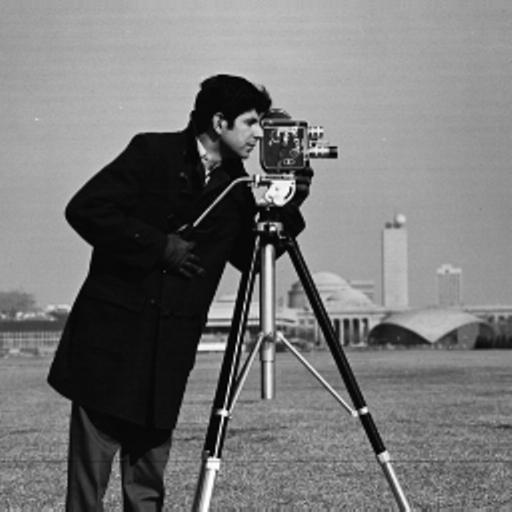

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("lab3_input.jpg").convert("RGB")
display(img)


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print("Original size:", (width, height))

# scaling factors
cx = 2
cy = 2
new_width = int(width * cx)
new_height = int(height * cy)


Original size: (512, 512)


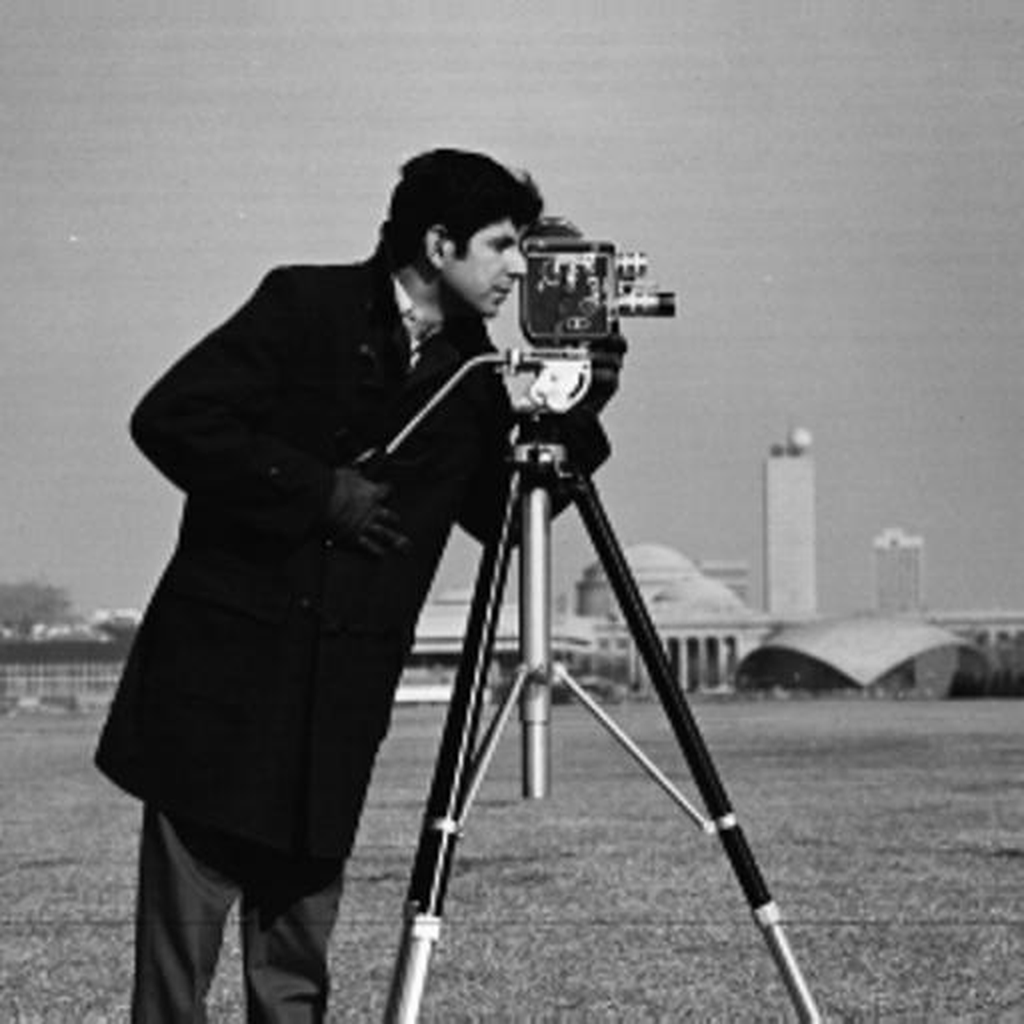

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

scaled_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
display(scaled_img)


In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)


Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx = 2
cy = 1

non_uniform_width = int(width * cx)
non_uniform_height = int(height * cy)


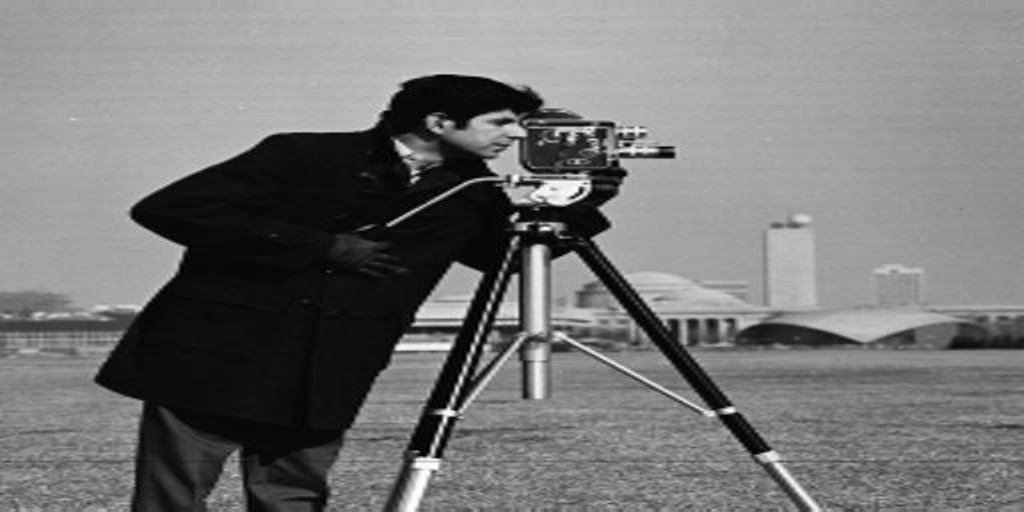

In [7]:
non_uniform_img = img.resize(
    (non_uniform_width, non_uniform_height),
    Image.Resampling.LANCZOS
)

display(non_uniform_img)

In [8]:
non_uniform_img.save("task1_1_non_uniform_scaled.jpg")

print("Original size:", img.size)
print("Non-uniform scaled size:", non_uniform_img.size)


Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Rotated size: (700, 700)


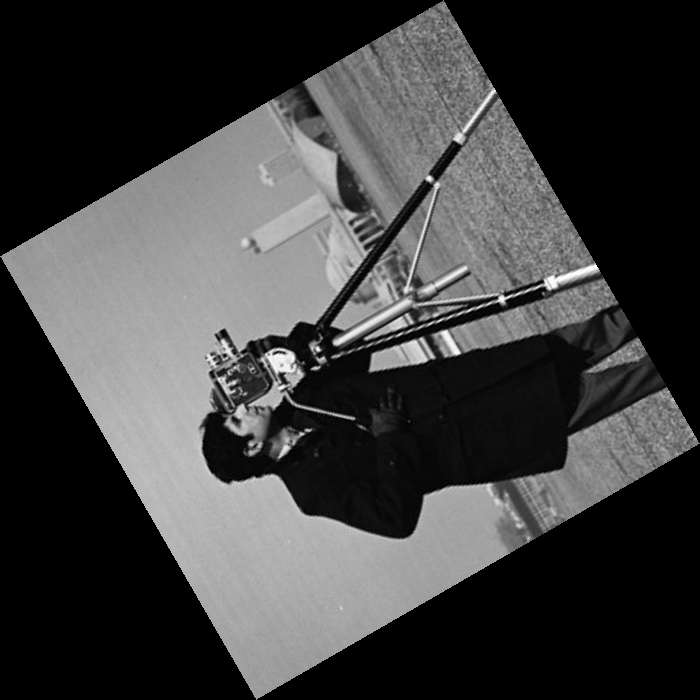

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True
)

# Save the rotated image
rotated_img.save("task1_2_rotated.jpg")
print("Rotated size:", rotated_img.size)
display(rotated_img)


### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Image dimensions:", width, "x", height)


Image dimensions: 512 x 512


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

# Increase canvas width so the whole sheared image fits
new_width = int(width + abs(shear_factor) * height)
new_height = height

# Translation keeps the result inside the canvas for positive shear
tx = 0
ty = 0


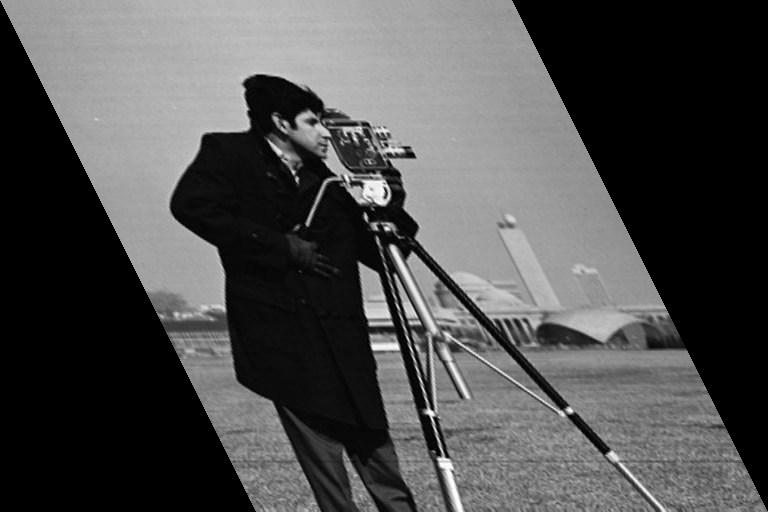

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shear_factor, tx, 0, 1, ty),
    resample=Image.Resampling.BICUBIC,
    fillcolor=(0, 0, 0)
)

display(sheared_img)

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")
print("Sheared size:", sheared_img.size)


Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

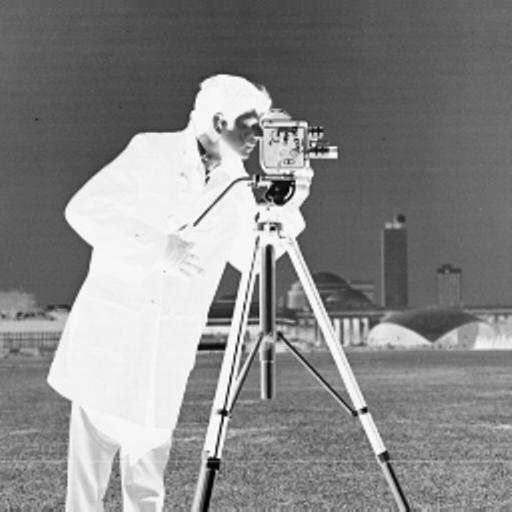

In [14]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img_numpy = Image.fromarray(negative_arr.astype(np.uint8))

negative_img_numpy.save("task2_1_negative_numpy.jpg")
display(negative_img_numpy)



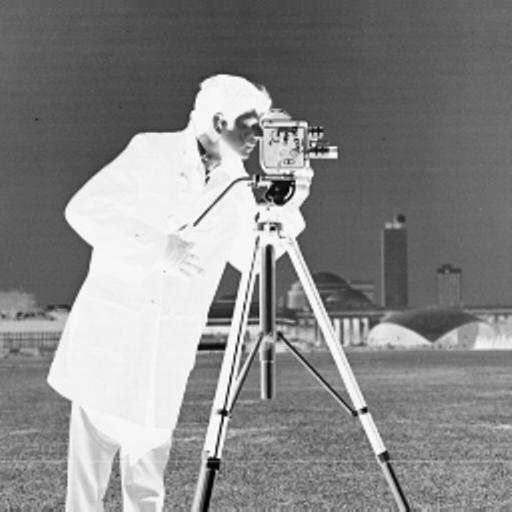

In [15]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img)

negative_img_pil.save("task2_1_negative_pil.jpg")
display(negative_img_pil)


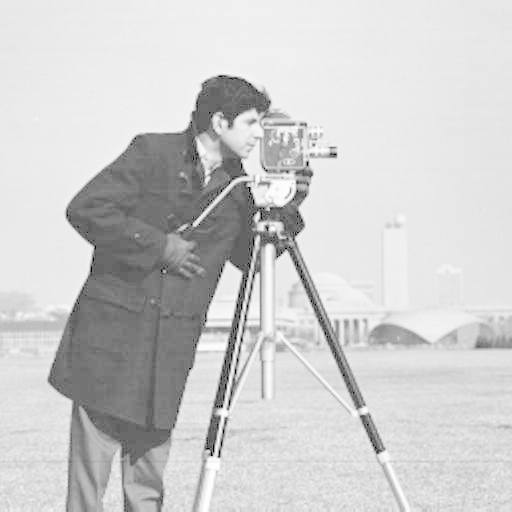

In [16]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

arr_float = np.array(img).astype(np.float32)

c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr_float)

# Clip and convert back to uint8
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)
log_transformed_img = Image.fromarray(log_transformed_arr)

log_transformed_img.save("task2_2_log.jpg")
display(log_transformed_img)


Gamma: 0.5


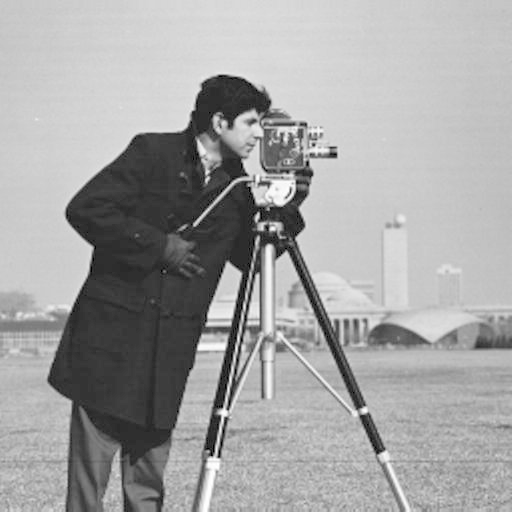

In [17]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5
arr_float = np.array(img).astype(np.float32) / 255.0

gamma_arr = 255 * np.power(arr_float, gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_arr)
gamma_img.save("task2_3_gamma.jpg")

print("Gamma:", gamma)
display(gamma_img)

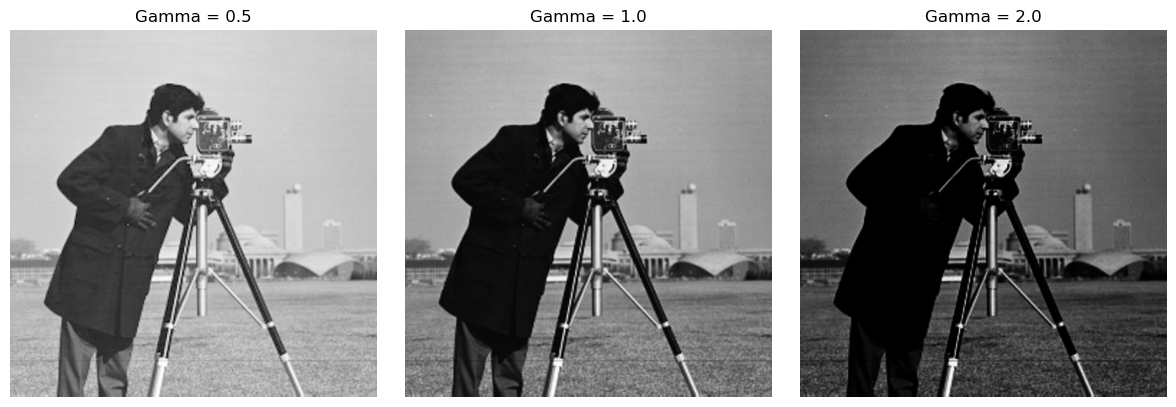

In [18]:
# Compare several gamma values
gamma_values = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(gamma_values), figsize=(12, 4))

for ax, gamma in zip(axes, gamma_values):
    corrected = 255 * np.power(
        np.array(img).astype(np.float32) / 255.0,
        gamma
    )
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    corrected_img = Image.fromarray(corrected)

    ax.imshow(corrected_img)
    ax.set_title(f"Gamma = {gamma}")
    ax.axis("off")

plt.tight_layout()
plt.show()